# EDA 10 - Revenue Outlier and Anomaly Detection

This notebook detects unusual high and low revenue days using `sales.csv`, checks whether anomalies overlap with optional business context files when available, and previews leakage-safe anomaly-related forecast features.

## 1. Setup and file discovery

Locate the primary sales file and optional context files recursively from the current working directory. The notebook displays all outputs directly and does not save EDA artifacts.

In [1]:
import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 260)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 180)

PROJECT_ROOT = Path(os.getcwd())
PRIMARY_FILE = "sales.csv"
OPTIONAL_FILES = ["promotions.csv", "inventory.csv", "web_traffic.csv", "returns.csv", "payments.csv"]
ALL_FILES = [PRIMARY_FILE] + OPTIONAL_FILES

analysis_ready = False
warning_messages = []
loaded_files = {}
load_errors = {}
file_paths = {}
daily = pd.DataFrame()
daily_continuous = pd.DataFrame()
global_anomaly_candidates = pd.DataFrame()
rolling_anomalies_df = pd.DataFrame()
all_anomaly_days = pd.DataFrame()
context_overlap_summary_df = pd.DataFrame()
context_overlap_examples_df = pd.DataFrame()
treatment_recommendations_df = pd.DataFrame()
feature_preview = pd.DataFrame()

high_anomaly_count = 0
low_anomaly_count = 0
extreme_anomaly_dates = []
cluster_statement = "Not evaluated."
context_overlap_statement = "Not evaluated."
leakage_confirmation = "Not evaluated."
recommended_anomaly_features = [
    "is_revenue_spike_lag",
    "is_revenue_drop_lag",
    "is_anomaly_lag",
    "rolling_zscore_lag",
    "rolling_anomaly_high_lag",
    "rolling_anomaly_low_lag",
]


def money_formatter(value, _position=None):
    if pd.isna(value):
        return ""
    abs_value = abs(value)
    if abs_value >= 1_000_000_000:
        return f"{value / 1_000_000_000:,.1f}B"
    if abs_value >= 1_000_000:
        return f"{value / 1_000_000:,.1f}M"
    if abs_value >= 1_000:
        return f"{value / 1_000:,.0f}K"
    return f"{value:,.0f}"


currency_axis = FuncFormatter(money_formatter)

for filename in ALL_FILES:
    matches = sorted(PROJECT_ROOT.rglob(filename), key=lambda p: (len(p.parts), str(p).lower()))
    file_paths[filename] = matches[0] if matches else None

file_discovery_df = pd.DataFrame([
    {
        "file": filename,
        "required": filename == PRIMARY_FILE,
        "found": file_paths[filename] is not None,
        "path": str(file_paths[filename].relative_to(PROJECT_ROOT)) if file_paths[filename] else None,
        "match_count": len(sorted(PROJECT_ROOT.rglob(filename), key=lambda p: (len(p.parts), str(p).lower()))),
    }
    for filename in ALL_FILES
])

if file_paths[PRIMARY_FILE] is None:
    warning_messages.append("sales.csv was not found under the current working directory.")

missing_optional = [filename for filename in OPTIONAL_FILES if file_paths[filename] is None]
if missing_optional:
    warning_messages.append("Optional context files not found: " + ", ".join(missing_optional))

print(f"Project root: {PROJECT_ROOT}")
display(file_discovery_df)

Project root: D:\Code\Datathon 2026


,file,required,found,path,match_count
0,sales.csv,True,True,datathon-2026-round-1\sales.csv,1
1,promotions.csv,False,True,datathon-2026-round-1\promotions.csv,1
2,inventory.csv,False,True,datathon-2026-round-1\inventory.csv,1
3,web_traffic.csv,False,True,datathon-2026-round-1\web_traffic.csv,1
4,returns.csv,False,True,datathon-2026-round-1\returns.csv,1
5,payments.csv,False,True,datathon-2026-round-1\payments.csv,1


## 2. Load sales and optional context files

Load all available listed CSV files safely with pandas. Missing optional files are reported but do not stop the sales-only analysis.

In [2]:
load_rows = []
for filename in ALL_FILES:
    path = file_paths.get(filename)
    if path is None:
        loaded_files[filename] = None
        load_errors[filename] = "file not found"
        load_rows.append({
            "file": filename,
            "required": filename == PRIMARY_FILE,
            "loaded": False,
            "rows": np.nan,
            "columns": np.nan,
            "error": "file not found",
        })
        continue

    try:
        df = pd.read_csv(path, low_memory=False)
        loaded_files[filename] = df
        load_errors[filename] = ""
        load_rows.append({
            "file": filename,
            "required": filename == PRIMARY_FILE,
            "loaded": True,
            "rows": len(df),
            "columns": len(df.columns),
            "error": "",
        })
    except Exception as exc:
        loaded_files[filename] = None
        load_errors[filename] = repr(exc)
        warning_messages.append(f"Could not load {filename}: {repr(exc)}")
        load_rows.append({
            "file": filename,
            "required": filename == PRIMARY_FILE,
            "loaded": False,
            "rows": np.nan,
            "columns": np.nan,
            "error": repr(exc),
        })

load_summary_df = pd.DataFrame(load_rows)
display(load_summary_df)

for filename in ALL_FILES:
    df = loaded_files.get(filename)
    if df is not None:
        print(f"Preview: {filename}")
        display(df.head())

,file,required,loaded,rows,columns,error
0,sales.csv,True,True,3833,3,
1,promotions.csv,False,True,50,10,
2,inventory.csv,False,True,60247,17,
3,web_traffic.csv,False,True,3652,7,
4,returns.csv,False,True,39939,7,
5,payments.csv,False,True,646945,4,


Preview: sales.csv


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


Preview: promotions.csv


,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,NaN,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,NaN,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,NaN,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,NaN,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000


...

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
0,2013-01-01,9760,7253,39093,0.00514,102.9,organic_search
1,2013-01-02,10456,8151,47611,0.00406,120.5,organic_search
2,2013-01-03,10076,7458,36963,0.00401,263.6,direct
3,2013-01-04,9973,8063,53078,0.00562,151.8,direct
4,2013-01-05,10223,7882,36790,0.00525,168.6,referral


Preview: returns.csv


,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount
0,RET-000001,2,609,2012-07-25,late_delivery,6,52458.01
1,RET-000002,32,1862,2012-07-16,wrong_size,2,5141.37
2,RET-000003,35,2359,2012-07-16,wrong_size,1,5315.95
3,RET-000004,47,1449,2012-07-11,wrong_size,4,6493.75
4,RET-000005,47,1450,2012-07-25,wrong_size,1,1740.76


Preview: payments.csv


,order_id,payment_method,payment_value,installments
0,1,credit_card,7967.54,3
1,2,cod,71163.75,1
2,3,credit_card,33660.99,3
3,4,credit_card,53196.25,3
4,6,paypal,1597.84,1


## 3. Identify date and revenue columns

Detect the most likely date and revenue columns in `sales.csv` using normalized names, parse success, numeric suitability, and revenue-related naming hints. If no usable date or revenue column is found, the notebook warns and skips dependent sections.

In [3]:
def normalize_name(name):
    return re.sub(r"[^a-z0-9]+", "_", str(name).strip().lower()).strip("_")


def non_empty_mask(series):
    if pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series):
        return series.astype("string").str.strip().ne("") & series.notna()
    return series.notna()


def numeric_series(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    cleaned = (
        series.astype("string")
        .str.strip()
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace(r"^\((.*)\)$", r"-\1", regex=True)
    )
    return pd.to_numeric(cleaned, errors="coerce")


def parse_datetime_series(series):
    if pd.api.types.is_datetime64_any_dtype(series):
        return pd.to_datetime(series, errors="coerce")
    return pd.to_datetime(series, errors="coerce")


def date_score(column_name, series):
    name = normalize_name(column_name)
    name_tokens = set(name.split("_"))
    exact_date_names = {"date", "ds", "day", "sales_date", "order_date", "transaction_date", "created_at", "timestamp", "return_date", "snapshot_date", "start_date", "end_date"}
    date_terms = {"date", "day", "time", "timestamp", "datetime"}

    name_points = 0
    if name in exact_date_names:
        name_points += 5
    elif name_tokens & date_terms or any(term in name for term in ["date", "timestamp", "datetime"]):
        name_points += 3

    if pd.api.types.is_numeric_dtype(series) and name_points == 0:
        return {
            "column": column_name,
            "normalized_name": name,
            "date_score": -5.0,
            "date_parse_success": 0.0,
            "plausible_date_share": 0.0,
            "non_empty_values": int(non_empty_mask(series).sum()),
        }

    parsed = parse_datetime_series(series)
    mask = non_empty_mask(series)
    non_empty = int(mask.sum())
    parsed_valid = parsed[mask].notna() if non_empty else pd.Series(dtype=bool)
    parse_success = float(parsed_valid.mean()) if non_empty else 0.0

    parsed_non_null = parsed[mask].dropna()
    if len(parsed_non_null):
        plausible = parsed_non_null.between(pd.Timestamp("1990-01-01"), pd.Timestamp("2100-12-31"))
        plausible_share = float(plausible.mean())
        unique_dates = int(parsed_non_null.dt.normalize().nunique())
    else:
        plausible_share = 0.0
        unique_dates = 0

    score = name_points + (3 * parse_success) + (2 * plausible_share) + min(unique_dates / 20, 1)
    return {
        "column": column_name,
        "normalized_name": name,
        "date_score": round(score, 4),
        "date_parse_success": round(parse_success, 4),
        "plausible_date_share": round(plausible_share, 4),
        "non_empty_values": non_empty,
    }


def revenue_score(column_name, series):
    name = normalize_name(column_name)
    name_tokens = set(name.split("_"))
    positive_terms = {
        "revenue": 7,
        "sales": 5,
        "sale": 4,
        "amount": 4,
        "total": 3,
        "value": 2,
        "gmv": 5,
        "turnover": 5,
        "net": 2,
        "gross": 2,
    }
    negative_terms = {
        "id": 6,
        "key": 5,
        "code": 4,
        "date": 6,
        "time": 5,
        "year": 4,
        "month": 4,
        "day": 4,
        "qty": 5,
        "quantity": 5,
        "count": 4,
        "cost": 4,
        "cogs": 5,
        "price": 2,
        "rate": 3,
        "percent": 4,
        "percentage": 4,
    }

    name_points = 0
    for term, points in positive_terms.items():
        if term in name_tokens or term in name:
            name_points += points

    penalty = 0
    for term, points in negative_terms.items():
        if term in name_tokens or term in name:
            penalty += points

    numeric = numeric_series(series)
    mask = non_empty_mask(series)
    non_empty = int(mask.sum())
    numeric_non_null = int(numeric[mask].notna().sum()) if non_empty else 0
    numeric_success = numeric_non_null / non_empty if non_empty else 0.0
    numeric_valid = numeric[mask].dropna()

    if len(numeric_valid):
        positive_share = float((numeric_valid > 0).mean())
        nonzero_share = float((numeric_valid != 0).mean())
        mean_value = float(numeric_valid.mean())
        std_value = float(numeric_valid.std(ddof=1)) if len(numeric_valid) > 1 else 0.0
        abs_median = float(numeric_valid.abs().median())
    else:
        positive_share = 0.0
        nonzero_share = 0.0
        mean_value = np.nan
        std_value = np.nan
        abs_median = 0.0

    variability_points = 1.0 if pd.notna(std_value) and std_value > 0 else 0.0
    magnitude_points = min(np.log10(abs_median + 1) / 4, 1.5) if abs_median > 0 else 0.0
    score = name_points - penalty + (3 * numeric_success) + positive_share + nonzero_share + variability_points + magnitude_points

    return {
        "column": column_name,
        "normalized_name": name,
        "revenue_score": round(float(score), 4),
        "numeric_parse_success": round(float(numeric_success), 4),
        "positive_share": round(float(positive_share), 4),
        "non_empty_values": non_empty,
        "numeric_values": numeric_non_null,
        "mean_numeric_value": mean_value,
        "std_numeric_value": std_value,
        "has_revenue_name_hint": any(term in name for term in ["revenue", "sales", "amount", "gmv", "turnover"]),
    }


sales_raw = loaded_files.get(PRIMARY_FILE)
if sales_raw is None or sales_raw.empty:
    date_col = None
    revenue_col = None
    parsed_date = None
    parsed_revenue = None
    date_candidates_df = pd.DataFrame()
    revenue_candidates_df = pd.DataFrame()
    column_detection_df = pd.DataFrame([{"warning": "sales.csv was not loaded or is empty."}])
    warning_messages.append("Column detection skipped because sales.csv was not loaded or is empty.")
else:
    date_candidates_df = pd.DataFrame([date_score(col, sales_raw[col]) for col in sales_raw.columns])
    revenue_candidates_df = pd.DataFrame([revenue_score(col, sales_raw[col]) for col in sales_raw.columns])

    date_candidates_df = date_candidates_df.sort_values(["date_score", "date_parse_success", "plausible_date_share"], ascending=False)
    revenue_candidates_df = revenue_candidates_df.sort_values(["revenue_score", "numeric_parse_success", "positive_share"], ascending=False)

    selected_date = date_candidates_df.iloc[0] if len(date_candidates_df) else None
    selected_revenue = revenue_candidates_df.iloc[0] if len(revenue_candidates_df) else None

    date_col = None
    revenue_col = None
    if selected_date is not None and selected_date["date_parse_success"] >= 0.50 and selected_date["plausible_date_share"] >= 0.50:
        date_col = selected_date["column"]

    if selected_revenue is not None and selected_revenue["numeric_parse_success"] >= 0.75 and selected_revenue["revenue_score"] >= 2.0:
        revenue_col = selected_revenue["column"]

    parsed_date = parse_datetime_series(sales_raw[date_col]) if date_col else None
    parsed_revenue = numeric_series(sales_raw[revenue_col]) if revenue_col else None

    if date_col is None:
        warning_messages.append("No usable date column was found. Anomaly EDA cannot be completed.")
    if revenue_col is None:
        warning_messages.append("No usable revenue or revenue-like numeric column was found. Anomaly EDA cannot be completed.")
    elif not bool(selected_revenue["has_revenue_name_hint"]):
        warning_messages.append(f"Revenue column was inferred from numeric data rather than a direct revenue name: {revenue_col}.")

    column_detection_df = pd.DataFrame([{
        "selected_date_column": date_col,
        "selected_revenue_column": revenue_col,
        "date_parse_success": float(parsed_date.notna().mean()) if parsed_date is not None else np.nan,
        "revenue_numeric_success": float(parsed_revenue.notna().mean()) if parsed_revenue is not None else np.nan,
        "revenue_inferred_without_name_hint": bool(revenue_col and not bool(selected_revenue["has_revenue_name_hint"])),
    }])

print("Selected sales columns")
display(column_detection_df)
if len(date_candidates_df):
    print("Date candidates")
    display(date_candidates_df)
if len(revenue_candidates_df):
    print("Revenue candidates")
    display(revenue_candidates_df)

Selected sales columns


,selected_date_column,selected_revenue_column,date_parse_success,revenue_numeric_success,revenue_inferred_without_name_hint
0,Date,Revenue,1.0,1.0,False


Date candidates


,column,normalized_name,date_score,date_parse_success,plausible_date_share,non_empty_values
0,Date,date,11.0,1.0,1.0,3833
1,Revenue,revenue,-5.0,0.0,0.0,3833
2,COGS,cogs,-5.0,0.0,0.0,3833


Revenue candidates


,column,normalized_name,revenue_score,numeric_parse_success,positive_share,non_empty_values,numeric_values,mean_numeric_value,std_numeric_value,has_revenue_name_hint
1,Revenue,revenue,14.5,1.0,1.0,3833,3833,4.286584e+06,2.624840e+06,True
2,COGS,cogs,2.5,1.0,1.0,3833,3833,3.695134e+06,2.219789e+06,False
0,Date,date,-6.0,0.0,0.0,3833,0,NaN,NaN,False


## 4. Prepare daily revenue time series

Parse dates and revenue, aggregate duplicated dates by summing revenue, sort by date, and create a continuous daily calendar index. Missing dates remain `NaN` rather than being filled with artificial revenue.

In [4]:
if sales_raw is None or date_col is None or revenue_col is None:
    analysis_ready = False
    prep_summary_df = pd.DataFrame([{"ready": False, "warning": "Missing loaded sales data, date column, or revenue column."}])
    display(prep_summary_df)
else:
    work = pd.DataFrame({
        "date_raw": sales_raw[date_col],
        "revenue_raw": sales_raw[revenue_col],
        "date": parsed_date,
        "revenue": parsed_revenue,
    })
    work["date"] = pd.to_datetime(work["date"], errors="coerce").dt.normalize()

    initial_rows = len(work)
    invalid_date_rows = int(work["date"].isna().sum())
    invalid_revenue_rows = int(work["revenue"].isna().sum())
    work = work.dropna(subset=["date", "revenue"]).copy()

    if work.empty:
        analysis_ready = False
        warning_messages.append("No rows remained after dropping invalid dates or revenue values.")
        prep_summary_df = pd.DataFrame([{
            "ready": False,
            "initial_rows": initial_rows,
            "invalid_date_rows": invalid_date_rows,
            "invalid_revenue_rows": invalid_revenue_rows,
            "usable_rows": 0,
        }])
        display(prep_summary_df)
    else:
        duplicate_date_rows = int(work.duplicated("date", keep=False).sum())
        daily = (
            work.groupby("date", as_index=False)
            .agg(revenue=("revenue", "sum"), source_rows=("revenue", "size"))
            .sort_values("date")
            .reset_index(drop=True)
        )

        full_calendar = pd.date_range(daily["date"].min(), daily["date"].max(), freq="D")
        daily_continuous = (
            daily.set_index("date")
            .reindex(full_calendar)
            .rename_axis("date")
            .reset_index()
        )
        daily_continuous["was_observed"] = daily_continuous["revenue"].notna()
        daily_continuous["source_rows"] = daily_continuous["source_rows"].fillna(0).astype(int)
        daily_continuous["year"] = daily_continuous["date"].dt.year
        daily_continuous["month"] = daily_continuous["date"].dt.month
        daily_continuous["year_month"] = daily_continuous["date"].dt.to_period("M")
        daily_continuous["day_index"] = np.arange(len(daily_continuous))

        observed_dates = pd.DatetimeIndex(daily["date"])
        missing_dates = full_calendar.difference(observed_dates)
        inferred_frequency = pd.infer_freq(observed_dates) if len(observed_dates) >= 3 else None
        median_gap_days = float(daily["date"].diff().dt.days.dropna().median()) if len(daily) > 1 else np.nan

        analysis_ready = True
        if duplicate_date_rows:
            warning_messages.append(f"Found {duplicate_date_rows:,} source rows on dates with duplicates; revenue was aggregated by date using sum.")
        if len(missing_dates):
            warning_messages.append(f"Found {len(missing_dates):,} missing calendar dates between the first and last observed sales dates; these remain missing.")
        if pd.notna(median_gap_days) and median_gap_days > 1:
            warning_messages.append(f"Observed dates are not contiguous daily records; median gap is {median_gap_days:.1f} days.")

        prep_summary_df = pd.DataFrame([{
            "ready": True,
            "initial_rows": initial_rows,
            "invalid_date_rows": invalid_date_rows,
            "invalid_revenue_rows": invalid_revenue_rows,
            "usable_source_rows": len(work),
            "daily_observed_rows_after_aggregation": len(daily),
            "continuous_calendar_rows": len(daily_continuous),
            "duplicate_date_source_rows": duplicate_date_rows,
            "first_date": daily["date"].min().date(),
            "last_date": daily["date"].max().date(),
            "missing_calendar_days": len(missing_dates),
            "inferred_observed_frequency": inferred_frequency,
            "median_gap_days": median_gap_days,
        }])
        display(prep_summary_df)
        display(daily_continuous.head(10))

,ready,initial_rows,invalid_date_rows,invalid_revenue_rows,usable_source_rows,daily_observed_rows_after_aggregation,continuous_calendar_rows,duplicate_date_source_rows,first_date,last_date,missing_calendar_days,inferred_observed_frequency,median_gap_days
0,True,3833,0,0,3833,3833,3833,0,2012-07-04,2022-12-31,0,D,1.0


,date,revenue,source_rows,was_observed,year,month,year_month,day_index
0,2012-07-04,5123547.94,1,True,2012,7,2012-07,0
1,2012-07-05,2751773.45,1,True,2012,7,2012-07,1
2,2012-07-06,3054029.42,1,True,2012,7,2012-07,2
3,2012-07-07,2667930.94,1,True,2012,7,2012-07,3
4,2012-07-08,2360851.90,1,True,2012,7,2012-07,4
5,2012-07-09,3548386.46,1,True,2012,7,2012-07,5
6,2012-07-10,5234938.62,1,True,2012,7,2012-07,6
7,2012-07-11,5582884.78,1,True,2012,7,2012-07,7
8,2012-07-12,5734632.02,1,True,2012,7,2012-07,8
9,2012-07-13,5309511.71,1,True,2012,7,2012-07,9


## 5. Global outlier detection

Use interpretable global methods to identify unusual high and low revenue days: z-score, IQR rule, and percentile thresholds. These methods are descriptive and should not be used to remove data automatically.

In [5]:
def method_list(row):
    methods = []
    if row.get("global_z_high", False) or row.get("global_z_low", False):
        methods.append("global_zscore")
    if row.get("iqr_high", False) or row.get("iqr_low", False):
        methods.append("iqr_rule")
    if row.get("percentile_high", False) or row.get("percentile_low", False):
        methods.append("percentile_threshold")
    return ", ".join(methods)


def direction_from_flags(row):
    high = bool(row.get("global_high_anomaly", False))
    low = bool(row.get("global_low_anomaly", False))
    if high and low:
        return "mixed"
    if high:
        return "high"
    if low:
        return "low"
    return "none"


if not analysis_ready:
    print("WARNING: Skipping global outlier detection because usable daily revenue data is not available.")
else:
    valid_revenue = daily_continuous["revenue"].dropna()
    if len(valid_revenue) < 4 or valid_revenue.std(ddof=1) == 0:
        warning_messages.append("Not enough revenue variation for global outlier detection.")
        print("Not enough revenue variation for global outlier detection.")
    else:
        mean_revenue = valid_revenue.mean()
        std_revenue = valid_revenue.std(ddof=1)
        q1 = valid_revenue.quantile(0.25)
        q3 = valid_revenue.quantile(0.75)
        iqr = q3 - q1
        iqr_low_threshold = q1 - 1.5 * iqr
        iqr_high_threshold = q3 + 1.5 * iqr
        p01 = valid_revenue.quantile(0.01)
        p99 = valid_revenue.quantile(0.99)

        daily_continuous["global_zscore"] = (daily_continuous["revenue"] - mean_revenue) / std_revenue
        daily_continuous["revenue_percentile_rank"] = daily_continuous["revenue"].rank(pct=True)
        daily_continuous["global_z_high"] = daily_continuous["global_zscore"] >= 3
        daily_continuous["global_z_low"] = daily_continuous["global_zscore"] <= -3
        daily_continuous["iqr_high"] = daily_continuous["revenue"] > iqr_high_threshold
        daily_continuous["iqr_low"] = daily_continuous["revenue"] < iqr_low_threshold
        daily_continuous["percentile_high"] = daily_continuous["revenue"] >= p99
        daily_continuous["percentile_low"] = daily_continuous["revenue"] <= p01
        daily_continuous["global_high_anomaly"] = daily_continuous[["global_z_high", "iqr_high", "percentile_high"]].any(axis=1)
        daily_continuous["global_low_anomaly"] = daily_continuous[["global_z_low", "iqr_low", "percentile_low"]].any(axis=1)
        daily_continuous["global_anomaly"] = daily_continuous[["global_high_anomaly", "global_low_anomaly"]].any(axis=1)

        global_thresholds_df = pd.DataFrame([{
            "mean_revenue": mean_revenue,
            "std_revenue": std_revenue,
            "zscore_high_threshold": 3,
            "zscore_low_threshold": -3,
            "iqr_low_threshold": iqr_low_threshold,
            "iqr_high_threshold": iqr_high_threshold,
            "percentile_1_threshold": p01,
            "percentile_99_threshold": p99,
            "observed_revenue_days": len(valid_revenue),
        }])
        display(global_thresholds_df)

        global_anomaly_candidates = daily_continuous.loc[daily_continuous["global_anomaly"].fillna(False), [
            "date", "revenue", "global_zscore", "revenue_percentile_rank",
            "global_z_high", "global_z_low", "iqr_high", "iqr_low", "percentile_high", "percentile_low",
            "global_high_anomaly", "global_low_anomaly",
        ]].copy()
        if not global_anomaly_candidates.empty:
            global_anomaly_candidates["anomaly_method"] = global_anomaly_candidates.apply(method_list, axis=1)
            global_anomaly_candidates["anomaly_direction"] = global_anomaly_candidates.apply(direction_from_flags, axis=1)
            global_anomaly_candidates["abs_zscore"] = global_anomaly_candidates["global_zscore"].abs()
            global_anomaly_candidates = global_anomaly_candidates.sort_values("abs_zscore", ascending=False).reset_index(drop=True)

        high_outliers_df = global_anomaly_candidates.loc[global_anomaly_candidates["anomaly_direction"].isin(["high", "mixed"])].head(25)
        low_outliers_df = global_anomaly_candidates.loc[global_anomaly_candidates["anomaly_direction"].isin(["low", "mixed"])].head(25)
        print("Candidate high-revenue global outliers")
        display(high_outliers_df)
        print("Candidate low-revenue global outliers")
        display(low_outliers_df)

,mean_revenue,std_revenue,zscore_high_threshold,zscore_low_threshold,iqr_low_threshold,iqr_high_threshold,percentile_1_threshold,percentile_99_threshold,observed_revenue_days
0,4.286584e+06,2.624840e+06,3,-3,-1848593.75,9670559.77,845078.752,1.380199e+07,3833


Candidate high-revenue global outliers

,date,revenue,global_zscore,revenue_percentile_rank,global_z_high,global_z_low,iqr_high,iqr_low,percentile_high,percentile_low,global_high_anomaly,global_low_anomaly,anomaly_method,anomaly_direction,abs_zscore
0,2018-05-30,20905271.35,6.331314,1.000000,True,False,True,False,True,False,True,False,"global_zscore, iqr_rule, percentile_threshold",high,6.331314
1,2018-05-31,19289944.12,5.715914,0.999739,True,False,True,False,True,False,True,False,"global_zscore, iqr_rule, percentile_threshold",high,5.715914
2,2018-06-01,19245165.78,5.698854,0.999478,True,False,True,False,True,False,True,False,"global_zscore, iqr_rule, percentile_threshold",high,5.698854
3,2017-06-01,17639270.88,5.087048,0.999217,True,False,True,False,True,False,True,False,"global_zscore, iqr_rule, percentile_threshold",high,5.087048
4,2018-06-02,17529108.34,5.045078,0.998956,True,False,True,False,True,False,True,False,"global_zscore, iqr_rule, percentile_threshold",high,5.045078
5,2017-06-02,17528852.88,5.044981,0.998696,True,False,True,False,True,False,True,False,"global_zscore, iqr_rule, percentile_threshold",high,5.044981
6,2017-03-30,17516038.82,5.040099,0.998435,True,False,True,False,True,False,True,False,"global_zscore, iqr_rule, percentile_threshold",high,5.040099
7,2016-04-28,17388183.19,4.991389,0.998174,True,False,True,False,True,False,True,False,"global_zscore, iqr_rule, percentile_threshold",high,4.991389
8,2014-04-29,17347427.27,4.975862,0.997913,True,False,True,False,True,False,True,False,"global_zscore, iqr_rule, percentile_threshold",high,4.975862
9,2017-05-31,17314841.86,4.963448,0.997652,True,False,True,False,True,False,True,False,"global_zscore, iqr_rule, percentile_threshold",high,4.963448


Candidate low-revenue global outliers


,date,revenue,global_zscore,revenue_percentile_rank,global_z_high,global_z_low,iqr_high,iqr_low,percentile_high,percentile_low,global_high_anomaly,global_low_anomaly,anomaly_method,anomaly_direction,abs_zscore
169,2013-03-02,279813.94,-1.526482,0.000261,False,False,False,False,False,True,False,True,percentile_threshold,low,1.526482
170,2020-01-02,306693.87,-1.516241,0.000522,False,False,False,False,False,True,False,True,percentile_threshold,low,1.516241
171,2020-12-02,370653.23,-1.491874,0.000783,False,False,False,False,False,True,False,True,percentile_threshold,low,1.491874
172,2021-01-02,378420.41,-1.488915,0.001044,False,False,False,False,False,True,False,True,percentile_threshold,low,1.488915
173,2020-02-29,440505.08,-1.465262,0.001304,False,False,False,False,False,True,False,True,percentile_threshold,low,1.465262
174,2020-12-03,528608.48,-1.431697,0.001565,False,False,False,False,False,True,False,True,percentile_threshold,low,1.431697
175,2022-01-03,545563.72,-1.425237,0.001826,False,False,False,False,False,True,False,True,percentile_threshold,low,1.425237
176,2020-03-01,574193.42,-1.414330,0.002087,False,False,False,False,False,True,False,True,percentile_threshold,low,1.414330
177,2019-12-05,584316.21,-1.410474,0.002348,False,False,False,False,False,True,False,True,percentile_threshold,low,1.410474
178,2021-12-03,586748.17,-1.409547,0.002609,False,False,False,False,False,True,False,True,percentile_threshold,low,1.409547


## 6. Rolling anomaly detection

Compute leakage-safe rolling baselines from `revenue.shift(1)` and compare current revenue against recent history. The rolling z-score itself uses current revenue for EDA detection, but forecast features later shift the anomaly indicators before use.

In [6]:
if not analysis_ready:
    print("WARNING: Skipping rolling anomaly detection because usable daily revenue data is not available.")
else:
    shifted_revenue = daily_continuous["revenue"].shift(1)
    for window in [30, 90]:
        min_periods = max(10, int(window * 0.5))
        mean_col = f"rolling_mean_{window}"
        std_col = f"rolling_std_{window}"
        z_col = f"rolling_zscore_{window}"
        high_col = f"rolling_anomaly_high_{window}"
        low_col = f"rolling_anomaly_low_{window}"
        daily_continuous[mean_col] = shifted_revenue.rolling(window=window, min_periods=min_periods).mean()
        daily_continuous[std_col] = shifted_revenue.rolling(window=window, min_periods=min_periods).std()
        daily_continuous[z_col] = np.where(
            daily_continuous[std_col].abs() < 1e-9,
            np.nan,
            (daily_continuous["revenue"] - daily_continuous[mean_col]) / daily_continuous[std_col],
        )
        daily_continuous[high_col] = daily_continuous[z_col] >= 2.5
        daily_continuous[low_col] = daily_continuous[z_col] <= -2.5

    daily_continuous["rolling_high_anomaly"] = daily_continuous[["rolling_anomaly_high_30", "rolling_anomaly_high_90"]].any(axis=1)
    daily_continuous["rolling_low_anomaly"] = daily_continuous[["rolling_anomaly_low_30", "rolling_anomaly_low_90"]].any(axis=1)
    daily_continuous["rolling_anomaly"] = daily_continuous[["rolling_high_anomaly", "rolling_low_anomaly"]].any(axis=1)

    rolling_anomalies_df = daily_continuous.loc[daily_continuous["rolling_anomaly"].fillna(False), [
        "date", "revenue",
        "rolling_mean_30", "rolling_std_30", "rolling_zscore_30", "rolling_anomaly_high_30", "rolling_anomaly_low_30",
        "rolling_mean_90", "rolling_std_90", "rolling_zscore_90", "rolling_anomaly_high_90", "rolling_anomaly_low_90",
    ]].copy()
    if not rolling_anomalies_df.empty:
        rolling_anomalies_df["anomaly_direction"] = np.select(
            [
                rolling_anomalies_df[["rolling_anomaly_high_30", "rolling_anomaly_high_90"]].any(axis=1),
                rolling_anomalies_df[["rolling_anomaly_low_30", "rolling_anomaly_low_90"]].any(axis=1),
            ],
            ["high", "low"],
            default="mixed",
        )
        rolling_anomalies_df["max_abs_rolling_zscore"] = rolling_anomalies_df[["rolling_zscore_30", "rolling_zscore_90"]].abs().max(axis=1)
        rolling_anomalies_df = rolling_anomalies_df.sort_values("max_abs_rolling_zscore", ascending=False).reset_index(drop=True)

    print("Rolling anomaly candidates relative to shifted baselines")
    display(rolling_anomalies_df.head(50))

Rolling anomaly candidates relative to shifted baselines


,date,revenue,rolling_mean_30,rolling_std_30,rolling_zscore_30,rolling_anomaly_high_30,rolling_anomaly_low_30,rolling_mean_90,rolling_std_90,rolling_zscore_90,rolling_anomaly_high_90,rolling_anomaly_low_90,anomaly_direction,max_abs_rolling_zscore
0,2018-12-28,4637468.16,1.675042e+06,3.760809e+05,7.877098,True,False,2.480541e+06,1.103500e+06,1.954624,False,False,high,7.877098
1,2014-12-28,8484445.21,2.951236e+06,7.274075e+05,7.606753,True,False,3.368171e+06,1.051823e+06,4.864195,True,False,high,7.606753
2,2015-03-30,14251354.04,4.859060e+06,1.290129e+06,7.280122,True,False,4.041906e+06,1.533684e+06,6.656815,True,False,high,7.280122
3,2021-03-30,10795905.35,3.186893e+06,1.140869e+06,6.669491,True,False,2.342706e+06,1.195237e+06,7.072404,True,False,high,7.072404
4,2017-03-30,17516038.82,5.340342e+06,2.096673e+06,5.807150,True,False,4.115286e+06,1.923221e+06,6.967869,True,False,high,6.967869
5,2013-02-25,9128225.25,3.581892e+06,7.979952e+05,6.950334,True,False,3.382484e+06,1.215822e+06,4.725807,True,False,high,6.950334
6,2022-03-30,11643208.73,4.088960e+06,1.158359e+06,6.521508,True,False,2.914577e+06,1.378723e+06,6.330954,True,False,high,6.521508
7,2013-12-29,6516622.75,2.572751e+06,6.254467e+05,6.305689,True,False,3.155099e+06,1.080226e+06,3.111872,True,False,high,6.305689
8,2016-03-30,14545392.64,5.129941e+06,1.847711e+06,5.095737,True,False,4.484940e+06,1.603760e+06,6.273040,True,False,high,6.273040
9,2012-12-28,8573663.31,3.203379e+06,8.882571e+05,6.045867,True,False,3.379901e+06,9.617857e+05,5.400124,True,False,high,6.045867


## 7. Visual anomaly inspection

Plot daily revenue with anomalies highlighted, inspect z-scores, and use year/month boxplots to see whether anomalies are isolated or part of broader seasonal or structural patterns.

Anomalies appear somewhat clustered: 60.7% occur within 3 days of a previous anomaly.
All anomaly days


,date,revenue,year,month,global_zscore,rolling_zscore_30,rolling_zscore_90,global_high_anomaly,global_low_anomaly,rolling_high_anomaly,rolling_low_anomaly,global_anomaly,rolling_anomaly,anomaly_direction,anomaly_source,max_abs_score
0,2012-07-31,9151622.14,2012,7,1.853461,4.007271,NaN,False,False,True,False,False,True,high,rolling_only,4.007271
1,2012-08-01,9148357.30,2012,8,1.852217,3.115134,NaN,False,False,True,False,False,True,high,rolling_only,3.115134
2,2012-08-02,9692427.00,2012,8,2.059494,2.970181,NaN,True,False,True,False,True,True,high,global_and_rolling,2.970181
3,2012-08-28,9508676.62,2012,8,1.989490,2.282168,2.871888,False,False,True,False,False,True,high,rolling_only,2.871888
4,2012-08-29,9260558.32,2012,8,1.894963,1.928270,2.518582,False,False,True,False,False,True,high,rolling_only,2.518582
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354,2022-12-03,753704.17,2022,12,-1.345941,-1.642223,-1.743692,False,True,False,False,True,False,low,global_only,1.743692
355,2022-12-04,664409.51,2022,12,-1.379960,-1.710722,-1.804262,False,True,False,False,True,False,low,global_only,1.804262
356,2022-12-07,760218.13,2022,12,-1.343459,-1.444457,-1.641400,False,True,False,False,True,False,low,global_only,1.641400
357,2022-12-08,818209.67,2022,12,-1.321366,-1.252782,-1.534329,False,True,False,False,True,False,low,global_only,1.534329


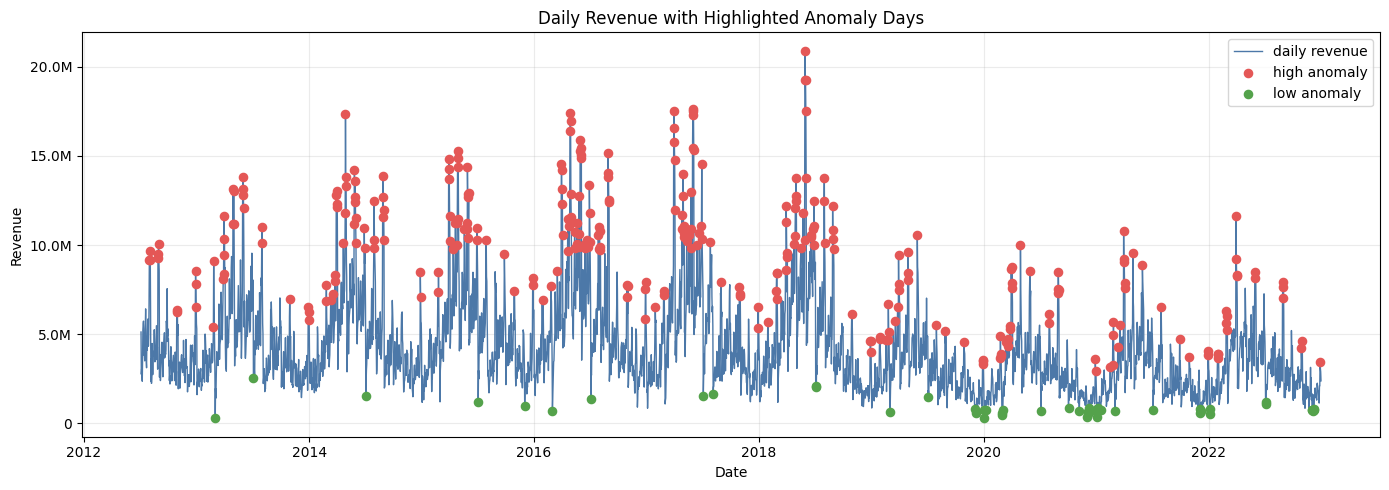

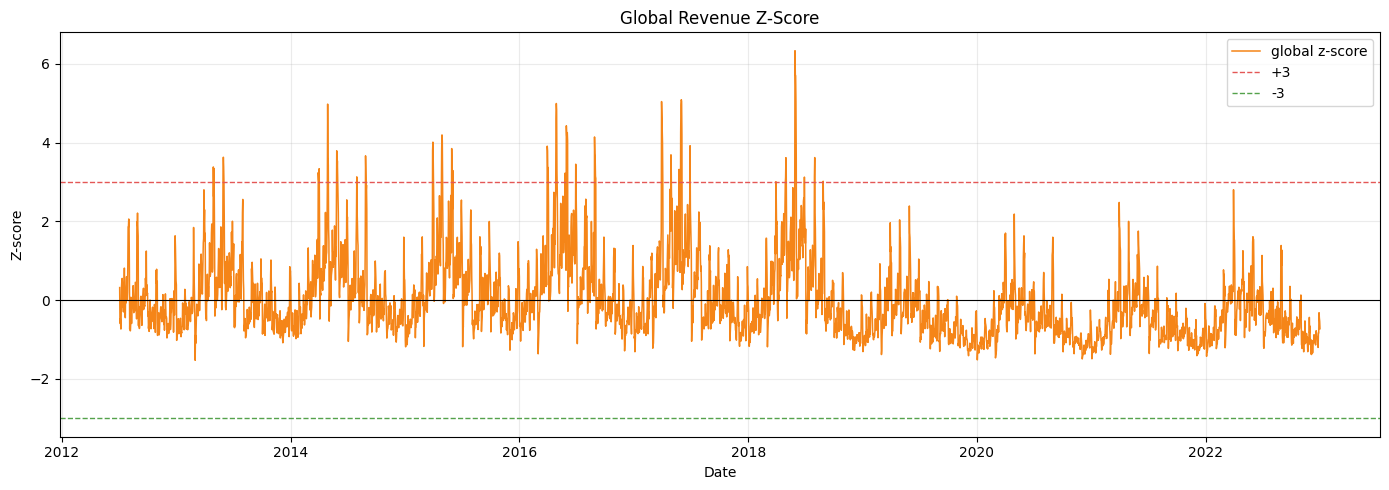

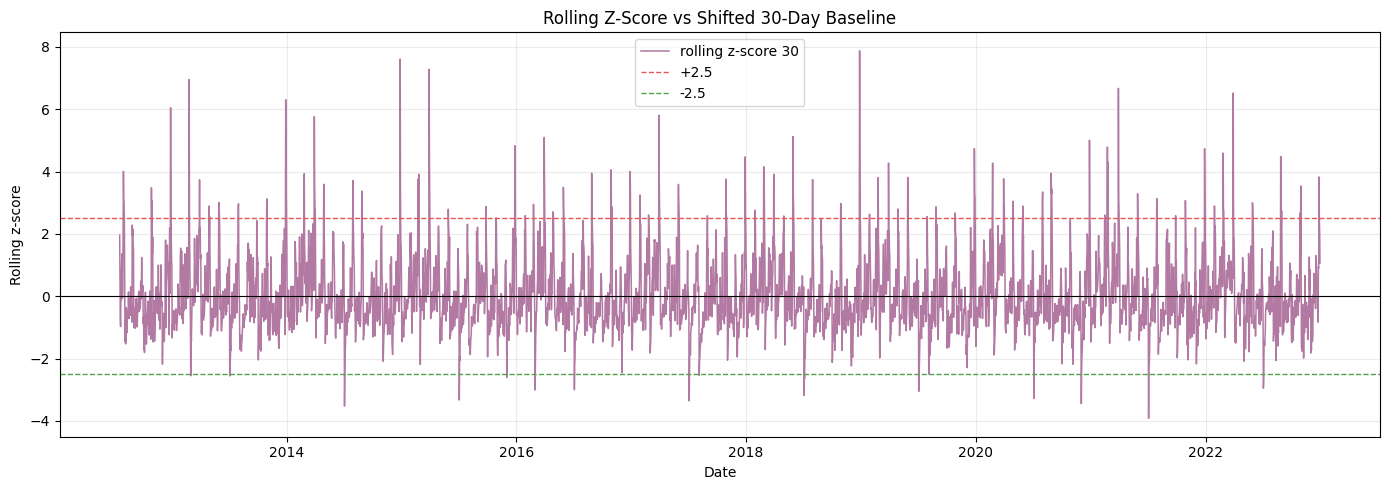

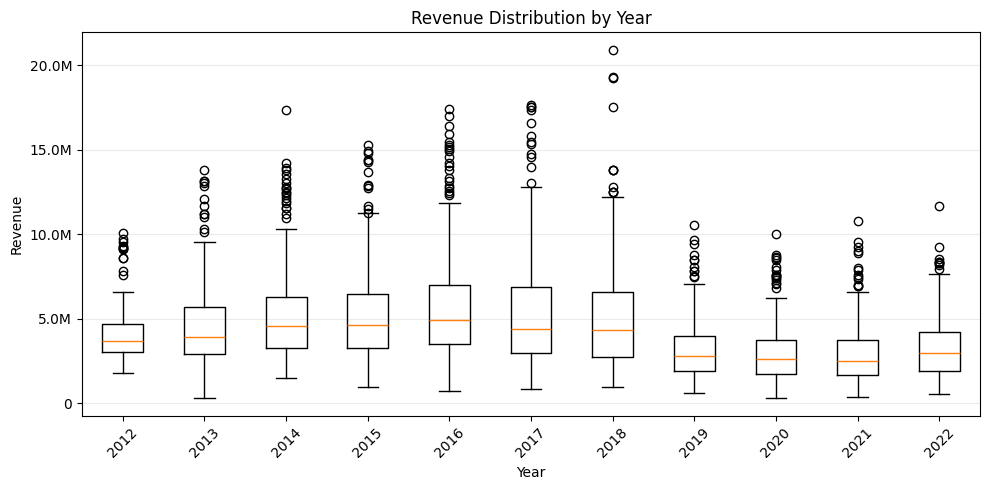

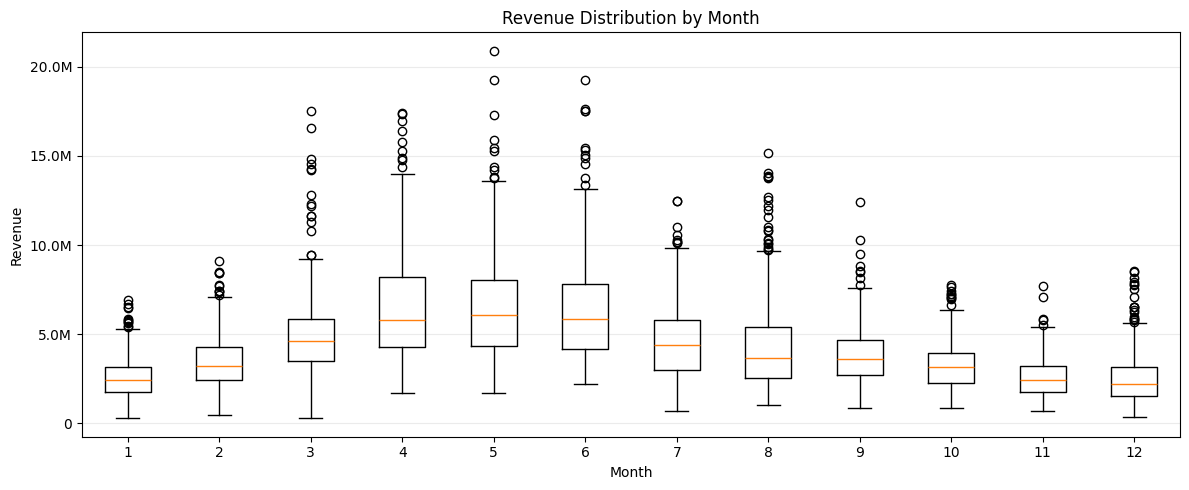

Anomaly counts by year-month


anomaly_direction,year_month,high,low
40,2016-10,2,0
41,2016-11,1,0
42,2016-12,3,0
43,2017-01,1,0
44,2017-02,2,0
45,2017-03,2,0
46,2017-04,7,0
47,2017-05,10,0
48,2017-06,8,0
49,2017-07,1,1


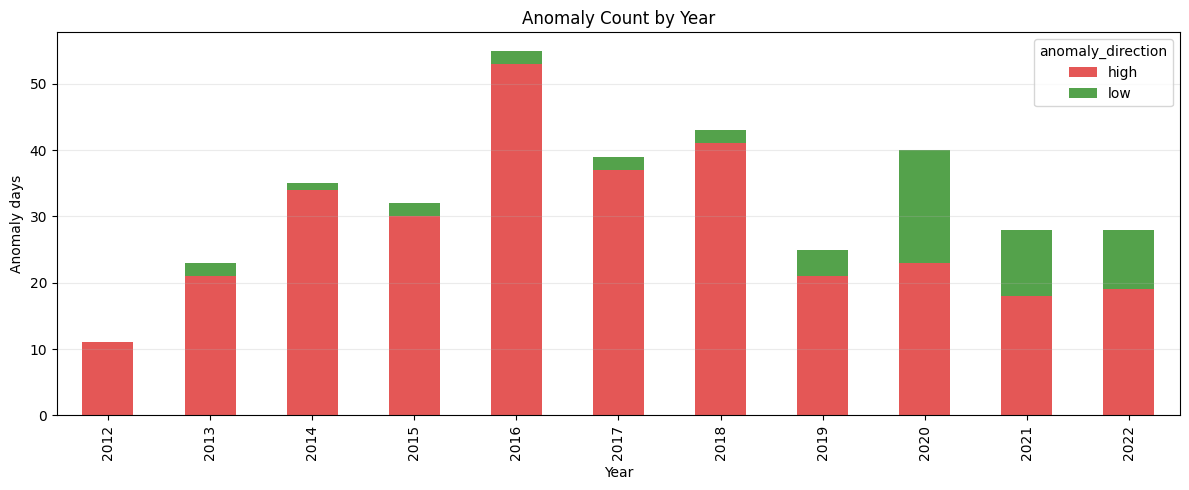

In [7]:
def build_all_anomaly_days():
    if daily_continuous.empty:
        return pd.DataFrame()
    temp = daily_continuous.loc[
        daily_continuous[["global_anomaly", "rolling_anomaly"]].fillna(False).any(axis=1),
        [
            "date", "revenue", "year", "month", "global_zscore", "rolling_zscore_30", "rolling_zscore_90",
            "global_high_anomaly", "global_low_anomaly", "rolling_high_anomaly", "rolling_low_anomaly",
            "global_anomaly", "rolling_anomaly",
        ],
    ].copy()
    if temp.empty:
        return temp
    temp["anomaly_direction"] = np.select(
        [
            temp[["global_high_anomaly", "rolling_high_anomaly"]].any(axis=1),
            temp[["global_low_anomaly", "rolling_low_anomaly"]].any(axis=1),
        ],
        ["high", "low"],
        default="mixed",
    )
    temp["anomaly_source"] = np.select(
        [temp["global_anomaly"] & temp["rolling_anomaly"], temp["global_anomaly"], temp["rolling_anomaly"]],
        ["global_and_rolling", "global_only", "rolling_only"],
        default="none",
    )
    temp["max_abs_score"] = temp[["global_zscore", "rolling_zscore_30", "rolling_zscore_90"]].abs().max(axis=1)
    return temp.sort_values("date").reset_index(drop=True)


if not analysis_ready:
    print("WARNING: Skipping visual anomaly inspection because usable daily revenue data is not available.")
else:
    all_anomaly_days = build_all_anomaly_days()
    high_anomaly_count = int((all_anomaly_days["anomaly_direction"] == "high").sum()) if not all_anomaly_days.empty else 0
    low_anomaly_count = int((all_anomaly_days["anomaly_direction"] == "low").sum()) if not all_anomaly_days.empty else 0
    extreme_anomaly_dates = (
        all_anomaly_days.sort_values("max_abs_score", ascending=False)["date"].dt.strftime("%Y-%m-%d").head(10).tolist()
        if not all_anomaly_days.empty else []
    )

    if all_anomaly_days.empty:
        cluster_statement = "No anomaly dates were detected by the configured global or rolling methods."
        print(cluster_statement)
    else:
        gap_days = all_anomaly_days["date"].diff().dt.days
        clustered_count = int((gap_days <= 3).sum())
        cluster_share = clustered_count / max(len(all_anomaly_days), 1)
        if cluster_share >= 0.40:
            cluster_statement = f"Anomalies appear somewhat clustered: {cluster_share:.1%} occur within 3 days of a previous anomaly."
        else:
            cluster_statement = f"Anomalies appear mostly isolated: {cluster_share:.1%} occur within 3 days of a previous anomaly."
        print(cluster_statement)
        print("All anomaly days")
        display(all_anomaly_days)

    plot_df = daily_continuous.dropna(subset=["revenue"]).copy()
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(plot_df["date"], plot_df["revenue"], color="#4C78A8", linewidth=1.0, label="daily revenue")
    if not all_anomaly_days.empty:
        high_points = all_anomaly_days.loc[all_anomaly_days["anomaly_direction"] == "high"]
        low_points = all_anomaly_days.loc[all_anomaly_days["anomaly_direction"] == "low"]
        ax.scatter(high_points["date"], high_points["revenue"], color="#E45756", s=35, label="high anomaly", zorder=3)
        ax.scatter(low_points["date"], low_points["revenue"], color="#54A24B", s=35, label="low anomaly", zorder=3)
    ax.set_title("Daily Revenue with Highlighted Anomaly Days")
    ax.set_xlabel("Date")
    ax.set_ylabel("Revenue")
    ax.yaxis.set_major_formatter(currency_axis)
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(daily_continuous["date"], daily_continuous["global_zscore"], color="#F58518", linewidth=1.1, label="global z-score")
    ax.axhline(3, color="#E45756", linestyle="--", linewidth=1, label="+3")
    ax.axhline(-3, color="#54A24B", linestyle="--", linewidth=1, label="-3")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("Global Revenue Z-Score")
    ax.set_xlabel("Date")
    ax.set_ylabel("Z-score")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(daily_continuous["date"], daily_continuous["rolling_zscore_30"], color="#B279A2", linewidth=1.1, label="rolling z-score 30")
    ax.axhline(2.5, color="#E45756", linestyle="--", linewidth=1, label="+2.5")
    ax.axhline(-2.5, color="#54A24B", linestyle="--", linewidth=1, label="-2.5")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("Rolling Z-Score vs Shifted 30-Day Baseline")
    ax.set_xlabel("Date")
    ax.set_ylabel("Rolling z-score")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

    years = sorted(plot_df["year"].dropna().unique())
    year_values = [plot_df.loc[plot_df["year"] == year, "revenue"].values for year in years]
    fig, ax = plt.subplots(figsize=(max(10, len(years) * 0.8), 5))
    ax.boxplot(year_values, tick_labels=[str(int(year)) for year in years], showfliers=True)
    ax.set_title("Revenue Distribution by Year")
    ax.set_xlabel("Year")
    ax.set_ylabel("Revenue")
    ax.yaxis.set_major_formatter(currency_axis)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

    month_values = [plot_df.loc[plot_df["month"] == month, "revenue"].values for month in range(1, 13)]
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.boxplot(month_values, tick_labels=[str(month) for month in range(1, 13)], showfliers=True)
    ax.set_title("Revenue Distribution by Month")
    ax.set_xlabel("Month")
    ax.set_ylabel("Revenue")
    ax.yaxis.set_major_formatter(currency_axis)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

    if not all_anomaly_days.empty:
        anomaly_year_month = (
            all_anomaly_days.assign(year_month=all_anomaly_days["date"].dt.to_period("M").astype(str))
            .groupby(["year_month", "anomaly_direction"])
            .size()
            .unstack("anomaly_direction", fill_value=0)
            .reset_index()
        )
        print("Anomaly counts by year-month")
        display(anomaly_year_month.tail(60))

        anomaly_by_year = all_anomaly_days.groupby(["year", "anomaly_direction"]).size().unstack("anomaly_direction", fill_value=0)
        fig, ax = plt.subplots(figsize=(12, 5))
        anomaly_by_year.plot(kind="bar", stacked=True, ax=ax, color=["#E45756", "#54A24B", "#B279A2"][:len(anomaly_by_year.columns)])
        ax.set_title("Anomaly Count by Year")
        ax.set_xlabel("Year")
        ax.set_ylabel("Anomaly days")
        ax.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        plt.show()

## 8. Context overlap analysis

Align optional context files by date where possible and inspect overlap with revenue anomalies. These are overlap checks only; they do not establish causality.

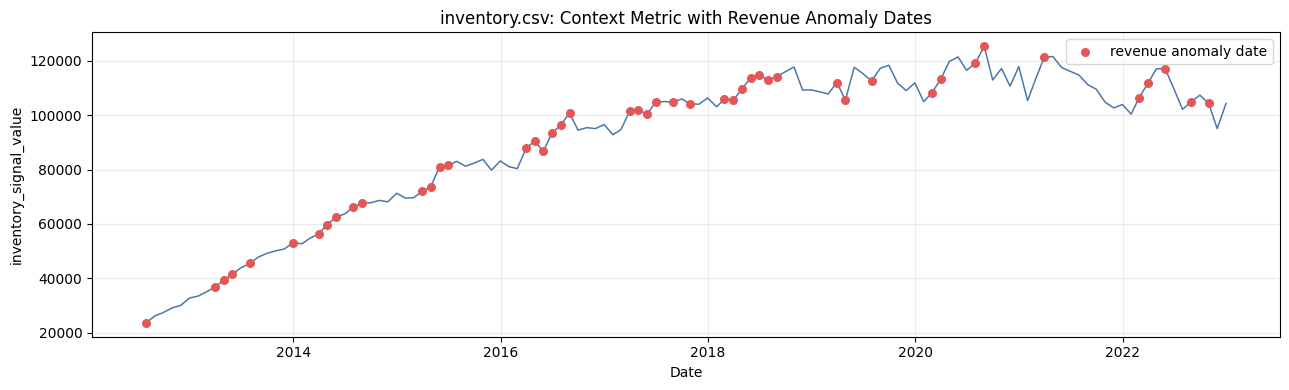

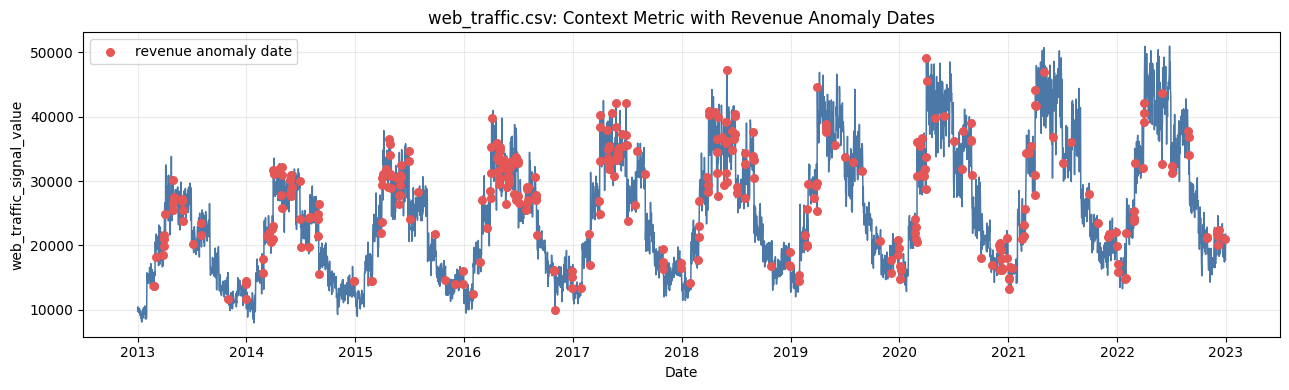

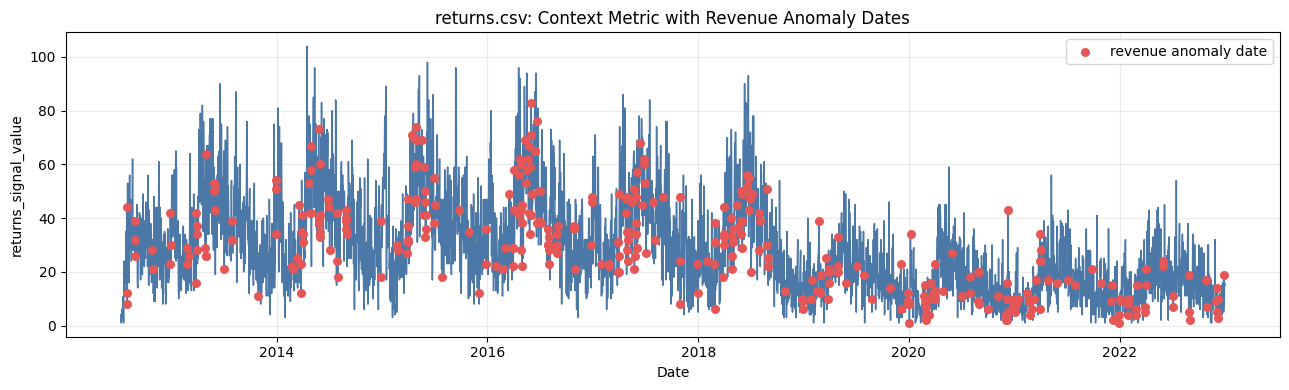

,context_file,status,date_column_used,signal_column_used,context_signal_dates,anomaly_days_checked,same_day_overlap_count,nearby_7day_overlap_count,high_anomaly_nearby_overlap_count,low_anomaly_nearby_overlap_count,note
0,promotions.csv,date-range expanded,start_date/end_date,active_promo_count,1707.0,359,161,203,158,45,Overlap only; no causal claim.
1,inventory.csv,date aggregated,snapshot_date,stock_on_hand,126.0,359,47,323,276,47,Overlap only; no causal claim.
2,web_traffic.csv,date aggregated,date,sessions,125.0,359,6,36,33,3,Overlap only; no causal claim.
3,returns.csv,date aggregated,return_date,return_quantity,162.0,359,15,129,121,8,Overlap only; no causal claim.
4,payments.csv,no usable date column for alignment,None,None,NaN,359,0,0,0,0,No date-aligned context signal available.


Available context signals overlap with anomaly dates or nearby windows 691 times across files.
Context overlap examples


,context_file,date,revenue,anomaly_direction,anomaly_source,max_abs_score,same_day_context_signal,nearby_7day_context_signal,active_promo_count,promo_discount_mean,promo_discount_max,inventory_signal_value,inventory_signal_zscore,web_traffic_signal_value,web_traffic_signal_zscore,returns_signal_value,returns_signal_zscore
0,promotions.csv,2013-02-24,5419232.89,high,rolling_only,2.636449,True,True,1.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN
1,promotions.csv,2013-02-25,9128225.25,high,rolling_only,6.950334,True,True,1.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN
2,promotions.csv,2013-03-02,279813.94,low,global_and_rolling,2.551078,False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,promotions.csv,2013-03-28,8099154.93,high,rolling_only,2.634316,True,True,1.0,12.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN
4,promotions.csv,2013-03-29,8381683.44,high,rolling_only,2.837550,True,True,1.0,12.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN
5,promotions.csv,2013-03-30,11636994.38,high,global_and_rolling,4.808674,True,True,1.0,12.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN
6,promotions.csv,2013-03-31,9455023.80,high,rolling_only,3.096563,True,True,1.0,12.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN
7,promotions.csv,2013-04-01,10313848.23,high,global_and_rolling,3.388623,True,True,1.0,12.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN
8,promotions.csv,2013-07-04,2521315.44,low,rolling_only,2.556665,True,True,1.0,18.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN
9,promotions.csv,2013-07-31,10104475.36,high,global_and_rolling,2.888204,True,True,1.0,50.0,50.0,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
def best_date_column_for_df(df):
    if df is None or df.empty:
        return None, pd.DataFrame()
    candidates = pd.DataFrame([date_score(col, df[col]) for col in df.columns])
    candidates = candidates.sort_values(["date_score", "date_parse_success", "plausible_date_share"], ascending=False)
    if candidates.empty:
        return None, candidates
    best = candidates.iloc[0]
    if best["date_parse_success"] >= 0.50 and best["plausible_date_share"] >= 0.50:
        return best["column"], candidates
    return None, candidates


def numeric_context_columns(df):
    cols = []
    for col in df.columns:
        values = numeric_series(df[col])
        success = values.notna().sum() / max(df[col].notna().sum(), 1)
        if success >= 0.70:
            cols.append(col)
    return cols


def zscore_safe(series):
    valid = series.dropna()
    if len(valid) < 4 or valid.std(ddof=1) == 0:
        return pd.Series(np.nan, index=series.index)
    return (series - valid.mean()) / valid.std(ddof=1)


def aggregate_context_by_date(filename, df):
    name = filename.replace(".csv", "")
    if df is None or df.empty:
        return pd.DataFrame(), {"status": "not loaded", "date_column": None, "signal_column": None}

    normalized_cols = {col: normalize_name(col) for col in df.columns}
    date_col_local, date_candidates = best_date_column_for_df(df)

    if filename == "promotions.csv":
        start_cols = [col for col, norm in normalized_cols.items() if "start" in norm and "date" in norm]
        end_cols = [col for col, norm in normalized_cols.items() if "end" in norm and "date" in norm]
        if start_cols and end_cols:
            start_col = start_cols[0]
            end_col = end_cols[0]
            promo = df.copy()
            promo["_start"] = parse_datetime_series(promo[start_col]).dt.normalize()
            promo["_end"] = parse_datetime_series(promo[end_col]).dt.normalize()
            promo = promo.dropna(subset=["_start", "_end"])
            if promo.empty:
                return pd.DataFrame(), {"status": "no valid promotion date ranges", "date_column": f"{start_col}/{end_col}", "signal_column": None}
            discount_cols = [col for col, norm in normalized_cols.items() if ("discount" in norm or "value" in norm) and col not in [start_col, end_col]]
            rows = []
            sales_min = daily_continuous["date"].min() if not daily_continuous.empty else promo["_start"].min()
            sales_max = daily_continuous["date"].max() if not daily_continuous.empty else promo["_end"].max()
            for _, promo_row in promo.iterrows():
                start = max(promo_row["_start"], sales_min)
                end = min(promo_row["_end"], sales_max)
                if start > end:
                    continue
                date_range = pd.date_range(start, end, freq="D")
                discount_value = np.nan
                if discount_cols:
                    discount_value = numeric_series(pd.Series([promo_row[discount_cols[0]]])).iloc[0]
                for date_value in date_range:
                    rows.append({"date": date_value, "active_promo_count": 1, "promo_discount_value": discount_value})
            if not rows:
                return pd.DataFrame(), {"status": "promotion ranges do not overlap sales dates", "date_column": f"{start_col}/{end_col}", "signal_column": None}
            daily_context = (
                pd.DataFrame(rows)
                .groupby("date", as_index=False)
                .agg(active_promo_count=("active_promo_count", "sum"), promo_discount_mean=("promo_discount_value", "mean"), promo_discount_max=("promo_discount_value", "max"))
            )
            daily_context["context_signal"] = daily_context["active_promo_count"] > 0
            return daily_context, {"status": "date-range expanded", "date_column": f"{start_col}/{end_col}", "signal_column": "active_promo_count"}

    if date_col_local is None:
        return pd.DataFrame(), {"status": "no usable date column for alignment", "date_column": None, "signal_column": None}

    temp = df.copy()
    temp["date"] = parse_datetime_series(temp[date_col_local]).dt.normalize()
    temp = temp.dropna(subset=["date"])
    if temp.empty:
        return pd.DataFrame(), {"status": "no valid parsed dates", "date_column": date_col_local, "signal_column": None}

    num_cols = numeric_context_columns(temp)
    num_cols = [col for col in num_cols if col != date_col_local]
    agg_dict = {col: (col, "sum") for col in num_cols}
    agg_dict["context_rows"] = (date_col_local, "size")
    daily_context = temp.groupby("date", as_index=False).agg(**agg_dict)

    signal_col = None
    signal_direction = "high"
    if filename == "inventory.csv":
        preferred = [col for col in num_cols if any(term in normalize_name(col) for term in ["stockout_flag", "stockout_days", "stock_on_hand", "days_of_supply", "fill_rate"])]
        signal_col = preferred[0] if preferred else (num_cols[0] if num_cols else "context_rows")
        if "stock_on_hand" in normalize_name(signal_col) or "days_of_supply" in normalize_name(signal_col) or "fill_rate" in normalize_name(signal_col):
            signal_direction = "low"
    elif filename == "web_traffic.csv":
        preferred = [col for col in num_cols if any(term in normalize_name(col) for term in ["session", "visitor", "page_view", "traffic"])]
        signal_col = preferred[0] if preferred else (num_cols[0] if num_cols else "context_rows")
    elif filename == "returns.csv":
        preferred = [col for col in num_cols if any(term in normalize_name(col) for term in ["refund", "return_quantity", "return"])]
        signal_col = preferred[0] if preferred else (num_cols[0] if num_cols else "context_rows")
    elif filename == "payments.csv":
        preferred = [col for col in num_cols if any(term in normalize_name(col) for term in ["payment", "amount", "value"])]
        signal_col = preferred[0] if preferred else (num_cols[0] if num_cols else "context_rows")
    else:
        signal_col = num_cols[0] if num_cols else "context_rows"

    if signal_col not in daily_context.columns:
        signal_col = "context_rows"

    signal_z = zscore_safe(daily_context[signal_col])
    daily_context[f"{name}_signal_value"] = daily_context[signal_col]
    daily_context[f"{name}_signal_zscore"] = signal_z

    if filename == "inventory.csv":
        stockout_cols = [col for col in daily_context.columns if "stockout" in normalize_name(col)]
        if stockout_cols:
            daily_context["context_signal"] = daily_context[stockout_cols].sum(axis=1) > 0
        elif signal_direction == "low":
            daily_context["context_signal"] = signal_z <= -2
        else:
            daily_context["context_signal"] = signal_z >= 2
    elif filename == "web_traffic.csv":
        daily_context["context_signal"] = signal_z.abs() >= 2
    else:
        daily_context["context_signal"] = signal_z >= 2

    return daily_context, {"status": "date aggregated", "date_column": date_col_local, "signal_column": signal_col}


def nearest_context_signal_overlap(anomaly_dates, signal_dates, max_days=7):
    if len(anomaly_dates) == 0 or len(signal_dates) == 0:
        return pd.Series(False, index=anomaly_dates.index)
    signal_values = pd.Series(pd.to_datetime(signal_dates).dropna().unique()).sort_values().to_numpy(dtype="datetime64[ns]")
    flags = []
    for date_value in anomaly_dates:
        if pd.isna(date_value):
            flags.append(False)
            continue
        date_np = np.datetime64(pd.Timestamp(date_value))
        diffs = np.abs((signal_values - date_np).astype("timedelta64[D]").astype(int))
        flags.append(bool(len(diffs) and diffs.min() <= max_days))
    return pd.Series(flags, index=anomaly_dates.index)


if not analysis_ready:
    print("WARNING: Skipping context overlap analysis because revenue anomalies are not available.")
else:
    context_summary_rows = []
    example_frames = []
    context_daily_map = {}
    anomaly_base = all_anomaly_days[["date", "revenue", "anomaly_direction", "anomaly_source", "max_abs_score"]].copy() if not all_anomaly_days.empty else pd.DataFrame(columns=["date", "revenue", "anomaly_direction", "anomaly_source", "max_abs_score"])

    for filename in OPTIONAL_FILES:
        df = loaded_files.get(filename)
        context_daily, meta = aggregate_context_by_date(filename, df)
        context_daily_map[filename] = context_daily
        context_name = filename.replace(".csv", "")

        if context_daily.empty:
            context_summary_rows.append({
                "context_file": filename,
                "status": meta.get("status"),
                "date_column_used": meta.get("date_column"),
                "signal_column_used": meta.get("signal_column"),
                "anomaly_days_checked": len(anomaly_base),
                "same_day_overlap_count": 0,
                "nearby_7day_overlap_count": 0,
                "high_anomaly_nearby_overlap_count": 0,
                "low_anomaly_nearby_overlap_count": 0,
                "note": "No date-aligned context signal available.",
            })
            continue

        signal_dates = context_daily.loc[context_daily["context_signal"].fillna(False), "date"]
        merged = anomaly_base.merge(context_daily, on="date", how="left", suffixes=("", f"_{context_name}"))
        merged["same_day_context_signal"] = merged["context_signal"].fillna(False)
        merged["nearby_7day_context_signal"] = nearest_context_signal_overlap(merged["date"], signal_dates, max_days=7) if not merged.empty else pd.Series(dtype=bool)

        same_count = int(merged["same_day_context_signal"].sum()) if not merged.empty else 0
        near_count = int(merged["nearby_7day_context_signal"].sum()) if not merged.empty else 0
        high_near = int(((merged["anomaly_direction"] == "high") & merged["nearby_7day_context_signal"]).sum()) if not merged.empty else 0
        low_near = int(((merged["anomaly_direction"] == "low") & merged["nearby_7day_context_signal"]).sum()) if not merged.empty else 0

        context_summary_rows.append({
            "context_file": filename,
            "status": meta.get("status"),
            "date_column_used": meta.get("date_column"),
            "signal_column_used": meta.get("signal_column"),
            "context_signal_dates": int(len(signal_dates)),
            "anomaly_days_checked": len(anomaly_base),
            "same_day_overlap_count": same_count,
            "nearby_7day_overlap_count": near_count,
            "high_anomaly_nearby_overlap_count": high_near,
            "low_anomaly_nearby_overlap_count": low_near,
            "note": "Overlap only; no causal claim.",
        })

        example = merged.loc[merged["same_day_context_signal"] | merged["nearby_7day_context_signal"]].copy()
        if not example.empty:
            keep_cols = [
                "date", "revenue", "anomaly_direction", "anomaly_source", "max_abs_score",
                "same_day_context_signal", "nearby_7day_context_signal",
            ]
            signal_value_cols = [col for col in example.columns if col.endswith("_signal_value") or col.endswith("_signal_zscore") or col in ["active_promo_count", "promo_discount_mean", "promo_discount_max"]]
            example = example[keep_cols + signal_value_cols].head(20)
            example.insert(0, "context_file", filename)
            example_frames.append(example)

        if filename in ["web_traffic.csv", "returns.csv", "inventory.csv"] and not context_daily.empty:
            signal_cols = [col for col in context_daily.columns if col.endswith("_signal_value")]
            if signal_cols:
                chart_col = signal_cols[0]
                fig, ax = plt.subplots(figsize=(13, 4))
                ax.plot(context_daily["date"], context_daily[chart_col], linewidth=1.1, color="#4C78A8")
                if not anomaly_base.empty:
                    anomaly_marker = anomaly_base.merge(context_daily[["date", chart_col]], on="date", how="inner")
                    if not anomaly_marker.empty:
                        ax.scatter(anomaly_marker["date"], anomaly_marker[chart_col], color="#E45756", s=30, label="revenue anomaly date", zorder=3)
                ax.set_title(f"{filename}: Context Metric with Revenue Anomaly Dates")
                ax.set_xlabel("Date")
                ax.set_ylabel(chart_col)
                ax.grid(alpha=0.25)
                if not anomaly_base.empty:
                    ax.legend()
                plt.tight_layout()
                plt.show()

    context_overlap_summary_df = pd.DataFrame(context_summary_rows)
    context_overlap_examples_df = pd.concat(example_frames, ignore_index=True) if example_frames else pd.DataFrame()

    if not context_overlap_summary_df.empty:
        total_near = int(context_overlap_summary_df["nearby_7day_overlap_count"].fillna(0).sum())
        if total_near:
            context_overlap_statement = f"Available context signals overlap with anomaly dates or nearby windows {total_near} times across files."
        else:
            context_overlap_statement = "No anomaly overlap was found with available date-aligned context signals."

    display(context_overlap_summary_df)
    print(context_overlap_statement)
    if not context_overlap_examples_df.empty:
        print("Context overlap examples")
        display(context_overlap_examples_df)

## 9. Anomaly treatment recommendation framework

This framework recommends modeling actions by anomaly type. It does not remove or cap any original values. Treatment choices should be validated with backtesting and, where possible, business investigation.

In [9]:
treatment_recommendations_df = pd.DataFrame([
    {
        "anomaly_type": "High revenue anomaly with promotion or traffic overlap",
        "recommended_action": "Keep as real signal and create anomaly/context flags",
        "rationale": "May represent demand response or campaign-window behavior, but overlap is not causality.",
        "validation_needed": "Backtest flags and inspect campaign/traffic records.",
    },
    {
        "anomaly_type": "High revenue anomaly with no context overlap",
        "recommended_action": "Keep initially; investigate; optionally cap only in robust-model experiments",
        "rationale": "Could be genuine demand, reporting aggregation, or data issue.",
        "validation_needed": "Check raw orders/payments and compare model performance with robust losses or caps.",
    },
    {
        "anomaly_type": "Low revenue anomaly near inventory stockout or traffic drop signal",
        "recommended_action": "Create anomaly and context flags; investigate stockout/traffic mechanism",
        "rationale": "Low revenue may coincide with operational constraints or demand drops, but causal support is required.",
        "validation_needed": "Inspect inventory availability, traffic source changes, and order records.",
    },
    {
        "anomaly_type": "Isolated low revenue anomaly with no context signal",
        "recommended_action": "Keep initially and create lagged anomaly flag",
        "rationale": "Removing can hide true demand variability; lagged flags may help models recover after shocks.",
        "validation_needed": "Review missing-data and transaction completeness.",
    },
    {
        "anomaly_type": "Confirmed data entry, duplicate, or pipeline error",
        "recommended_action": "Correct or exclude only after confirmation",
        "rationale": "EDA alone cannot prove data errors.",
        "validation_needed": "Trace source system records and reconciliation totals.",
    },
    {
        "anomaly_type": "Recurring seasonal or structural high/low period",
        "recommended_action": "Keep as signal and model with calendar, lag, rolling, and anomaly features",
        "rationale": "Recurring behavior is usually forecasting signal rather than noise.",
        "validation_needed": "Evaluate with time-series cross-validation.",
    },
])

display(treatment_recommendations_df)
print("No anomalies are removed or capped in this notebook.")

,anomaly_type,recommended_action,rationale,validation_needed
0,High revenue anomaly with promotion or traffic overlap,Keep as real signal and create anomaly/context flags,"May represent demand response or campaign-window behavior, but overlap is not causality.",Backtest flags and inspect campaign/traffic records.
1,High revenue anomaly with no context overlap,Keep initially; investigate; optionally cap only in robust-model experiments,"Could be genuine demand, reporting aggregation, or data issue.",Check raw orders/payments and compare model performance with robust losses or caps.
2,Low revenue anomaly near inventory stockout or traffic drop signal,Create anomaly and context flags; investigate stockout/traffic mechanism,"Low revenue may coincide with operational constraints or demand drops, but causal support is required.","Inspect inventory availability, traffic source changes, and order records."
3,Isolated low revenue anomaly with no context signal,Keep initially and create lagged anomaly flag,Removing can hide true demand variability; lagged flags may help models recover after shocks.,Review missing-data and transaction completeness.
4,"Confirmed data entry, duplicate, or pipeline error",Correct or exclude only after confirmation,EDA alone cannot prove data errors.,Trace source system records and reconciliation totals.
5,Recurring seasonal or structural high/low period,"Keep as signal and model with calendar, lag, rolling, and anomaly features",Recurring behavior is usually forecasting signal rather than noise.,Evaluate with time-series cross-validation.


No anomalies are removed or capped in this notebook.


## 10. Leakage-safe anomaly feature preview

Create forecast-facing anomaly features by shifting anomaly indicators and rolling z-scores. For date `t`, these features only use anomaly information known before `t`.

In [10]:
if not analysis_ready:
    print("WARNING: Skipping anomaly feature preview because usable daily revenue data is not available.")
else:
    feature_base = daily_continuous[["date", "revenue"]].copy()
    feature_base["is_revenue_spike_lag"] = daily_continuous["global_high_anomaly"].fillna(False).shift(1)
    feature_base["is_revenue_drop_lag"] = daily_continuous["global_low_anomaly"].fillna(False).shift(1)
    feature_base["is_anomaly_lag"] = daily_continuous["global_anomaly"].fillna(False).shift(1)
    feature_base["rolling_zscore_lag"] = daily_continuous["rolling_zscore_30"].shift(1)
    feature_base["rolling_anomaly_high_lag"] = daily_continuous["rolling_anomaly_high_30"].fillna(False).shift(1)
    feature_base["rolling_anomaly_low_lag"] = daily_continuous["rolling_anomaly_low_30"].fillna(False).shift(1)

    bool_cols = ["is_revenue_spike_lag", "is_revenue_drop_lag", "is_anomaly_lag", "rolling_anomaly_high_lag", "rolling_anomaly_low_lag"]
    for col in bool_cols:
        feature_base[col] = feature_base[col].fillna(False).astype(bool)

    feature_preview = feature_base.loc[
        feature_base[bool_cols].any(axis=1) | feature_base["rolling_zscore_lag"].abs().ge(2.0).fillna(False)
    ].head(30)
    if feature_preview.empty:
        feature_preview = feature_base.head(30)

    display(feature_preview)
    leakage_confirmation = (
        "Forecast anomaly features are leakage-safe: anomaly indicators are computed first, then shifted by one day; rolling z-scores use shifted rolling mean/std baselines and are also shifted for forecast use."
    )
    print(leakage_confirmation)
    print("Recommended anomaly-related forecast features:", ", ".join(recommended_anomaly_features))

,date,revenue,is_revenue_spike_lag,is_revenue_drop_lag,is_anomaly_lag,rolling_zscore_lag,rolling_anomaly_high_lag,rolling_anomaly_low_lag
28,2012-08-01,9148357.30,False,False,False,4.007271,True,False
29,2012-08-02,9692427.00,False,False,False,3.115134,True,False
30,2012-08-03,9297269.95,True,False,True,2.970181,True,False
31,2012-08-04,6384195.03,False,False,False,2.343979,False,False
56,2012-08-29,9260558.32,False,False,False,2.282168,False,False
58,2012-08-31,9104678.52,True,False,True,2.140766,False,False
117,2012-10-29,5424539.10,False,False,False,3.483617,True,False
118,2012-10-30,6347274.89,False,False,False,2.111839,False,False
119,2012-10-31,4942677.89,False,False,False,3.066298,True,False
152,2012-12-03,2315389.05,False,False,False,-2.178989,False,False


Forecast anomaly features are leakage-safe: anomaly indicators are computed first, then shifted by one day; rolling z-scores use shifted rolling mean/std baselines and are also shifted for forecast use.
Recommended anomaly-related forecast features: is_revenue_spike_lag, is_revenue_drop_lag, is_anomaly_lag, rolling_zscore_lag, rolling_anomaly_high_lag, rolling_anomaly_low_lag


## 11. Key observations and warnings

Summarize anomaly counts, extreme dates, clustering, context overlap, treatment guidance, and leakage-safe feature recommendations. All findings are exploratory.

In [11]:
if analysis_ready:
    if not all_anomaly_days.empty:
        most_extreme = all_anomaly_days.sort_values("max_abs_score", ascending=False).head(5)
        extreme_text = "; ".join(
            f"{row.date.date()} ({row.anomaly_direction}, score {row.max_abs_score:.2f})"
            for row in most_extreme.itertuples()
        )
    else:
        extreme_text = "None detected"

    if context_overlap_summary_df.empty:
        context_text = "No date-aligned optional context analysis was available."
    else:
        useful_context = context_overlap_summary_df.loc[context_overlap_summary_df["nearby_7day_overlap_count"].fillna(0) > 0]
        if useful_context.empty:
            context_text = "No overlap found with available date-aligned context signals."
        else:
            context_text = "; ".join(
                f"{row.context_file}: {int(row.nearby_7day_overlap_count)} nearby overlaps"
                for row in useful_context.itertuples()
            )

    treatment_text = "Keep anomalies initially, create lagged anomaly flags, investigate context overlaps, and cap/exclude only after validation or confirmed data errors."

    print("Insight summary")
    print(f"- High-revenue anomalies detected: {high_anomaly_count}")
    print(f"- Low-revenue anomalies detected: {low_anomaly_count}")
    print(f"- Most extreme anomaly dates: {extreme_text}")
    print(f"- Isolation versus clustering: {cluster_statement}")
    print(f"- Context overlap: {context_text}")
    print(f"- Treatment guidance: {treatment_text}")
    print(f"- Recommended anomaly-related forecast features: {', '.join(recommended_anomaly_features)}")
    print(f"- Leakage safety: {leakage_confirmation}")
else:
    print("Insight summary")
    print("- Revenue anomaly detection could not be completed because usable date and revenue columns were not available.")

print("\nWarnings and data notes")
if warning_messages:
    for message in dict.fromkeys(warning_messages):
        print(f"- {message}")
else:
    print("- No critical warnings.")

Insight summary
- High-revenue anomalies detected: 308
- Low-revenue anomalies detected: 51
- Most extreme anomaly dates: 2018-12-28 (high, score 7.88); 2014-12-28 (high, score 7.61); 2015-03-30 (high, score 7.28); 2021-03-30 (high, score 7.07); 2017-03-30 (high, score 6.97)
- Isolation versus clustering: Anomalies appear somewhat clustered: 60.7% occur within 3 days of a previous anomaly.
- Context overlap: promotions.csv: 203 nearby overlaps; inventory.csv: 323 nearby overlaps; web_traffic.csv: 36 nearby overlaps; returns.csv: 129 nearby overlaps
- Treatment guidance: Keep anomalies initially, create lagged anomaly flags, investigate context overlaps, and cap/exclude only after validation or confirmed data errors.
- Recommended anomaly-related forecast features: is_revenue_spike_lag, is_revenue_drop_lag, is_anomaly_lag, rolling_zscore_lag, rolling_anomaly_high_lag, rolling_anomaly_low_lag
- Leakage safety: Forecast anomaly features are leakage-safe: anomaly indicators are computed fi